In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sklearn
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

## Volunteer Segments

We will start this segment analysis on the subset of the processed data that is identified as volunteers.

In [2]:
df_v = pd.read_csv('../data/processed/cev_volunteers.csv')

In [3]:
df_v.head()

,hrnumhou,supwgt,hubus_YES,gtmetsta_NONMETROPOLITAN,pesex_MALE,veteran_Yes,pehspnon_NON-HISPANIC,disability_Yes,action_Yes,meeting_Yes,...,citizen_type_Citizen,citizen_type_Naturalized,citizen_type_Non,work_status_Employed,work_status_Not Working,work_status_Unemployed,housing_unit_House,housing_unit_Mobile,housing_unit_Other,housing_unit_Unit
0,2,2743.1032,0,0,0,0,1,0,0,0,...,1,0,0,0,1,0,1,0,0,0
1,5,3734.6711,0,0,1,0,1,0,0,0,...,1,0,0,1,0,0,1,0,0,0
2,5,3619.4642,0,0,0,0,1,0,0,0,...,1,0,0,1,0,0,1,0,0,0
3,4,3063.2525,0,0,1,0,1,0,1,0,...,1,0,0,1,0,0,1,0,0,0
4,4,3411.9942,0,0,0,0,1,0,1,0,...,1,0,0,0,1,0,1,0,0,0


In [4]:
df_v.columns

Index(['hrnumhou', 'supwgt', 'hubus_YES', 'gtmetsta_NONMETROPOLITAN',
       'pesex_MALE', 'veteran_Yes', 'pehspnon_NON-HISPANIC', 'disability_Yes',
       'action_Yes', 'meeting_Yes', 'contact_Yes', 'boycott_Yes', 'org_Yes',
       'politicaldonor_Yes', 'donate_Yes', 'fftalk_encoded',
       'ffissues_encoded', 'ntalk_encoded', 'nissues_encoded',
       'favors_encoded', 'views_encoded', 'news_encoded', 'ed_level_encoded',
       'age_encoded', 'hhincome_encoded', 'hetenure_Free', 'hetenure_Owned',
       'hetenure_Rented', 'gereg_MIDWEST', 'gereg_NORTHEAST', 'gereg_SOUTH',
       'gereg_WEST', 'pemaritl_DIVORCED', 'pemaritl_MARRIED',
       'pemaritl_NEVER MARRIED', 'pemaritl_SEPARATED', 'pemaritl_WIDOWED',
       'voterstatus_NA', 'voterstatus_No', 'voterstatus_Yes', 'simrace_AIAN',
       'simrace_Asian', 'simrace_Biracial', 'simrace_Black', 'simrace_HPI',
       'simrace_Multiracial', 'simrace_White', 'citizen_type_Citizen',
       'citizen_type_Naturalized', 'citizen_type_Non', '

In [5]:
df_v.shape

(13724, 57)

The weights for these entries will left out during the process of scaling, applying PCA, and modeling We will revisit them for profiling after the model is made.

In [6]:
df_features = df_v.drop(columns=['supwgt'])

### Feature Scaling

I will be using a StandardScaler from sklearn on this dataset prior to performing PCA so that principal component vecotrs are not influenced by the varying scales present in our features.

In [7]:
scaler = StandardScaler()

In [8]:
df_scaled = scaler.fit_transform(df_features)

### Dimensionality Reduction & Principal Component Analysis

I will use sklearn's PCA class to perform principal component analysis on the datain order to find the vectors of maximal variance in the data. To start, I will not set any parameters so all components are computed.
Then I will visualize the individual component ratios of variance and cumulative variance explained to try and find an ideal number of components we can reduce our data down to while maintaining reasonable variance.
Once I've made a choice for the number of components to keep, I will re-fit a PCA instance to perform the decided-on transformation.

In [9]:
pca = PCA()

In [10]:
pca.fit(df_scaled)

,"n_components n_components: int, float or 'mle', default=NoneNumber of components to keep.if n_components is not set all components are kept:: n_components == min(n_samples, n_features)If ``n_components == 'mle'`` and ``svd_solver == 'full'``, Minka'sMLE is used to guess the dimension. Use of ``n_components == 'mle'``will interpret ``svd_solver == 'auto'`` as ``svd_solver == 'full'``.If ``0 < n_components < 1`` and ``svd_solver == 'full'``, select thenumber of components such that the amount of variance that needs to beexplained is greater than the percentage specified by n_components.If ``svd_solver == 'arpack'``, the number of components must bestrictly less than the minimum of n_features and n_samples.Hence, the None case results in:: n_components == min(n_samples, n_features) - 1",None
,"copy copy: bool, default=TrueIf False, data passed to fit are overwritten and runningfit(X).transform(X) will not yield the expected results,use fit_transform(X) instead.",True
,"whiten whiten: bool, default=FalseWhen True (False by default) the `components_` vectors are multipliedby the square root of n_samples and then divided by the singular valuesto ensure uncorrelated outputs with unit component-wise variances.Whitening will remove some information from the transformed signal(the relative variance scales of the components) but can sometimeimprove the predictive accuracy of the downstream estimators bymaking their data respect some hard-wired assumptions.",False
,"svd_solver svd_solver: {'auto', 'full', 'covariance_eigh', 'arpack', 'randomized'}, default='auto'""auto"" : The solver is selected by a default 'auto' policy is based on `X.shape` and `n_components`: if the input data has fewer than 1000 features and more than 10 times as many samples, then the ""covariance_eigh"" solver is used. Otherwise, if the input data is larger than 500x500 and the number of components to extract is lower than 80% of the smallest dimension of the data, then the more efficient ""randomized"" method is selected. Otherwise the exact ""full"" SVD is computed and optionally truncated afterwards.""full"" : Run exact full SVD calling the standard LAPACK solver via `scipy.linalg.svd` and select the components by postprocessing""covariance_eigh"" : Precompute the covariance matrix (on centered data), run a classical eigenvalue decomposition on the covariance matrix typically using LAPACK and select the components by postprocessing. This solver is very efficient for n_samples >> n_features and small n_features. It is, however, not tractable otherwise for large n_features (large memory footprint required to materialize the covariance matrix). Also note that compared to the ""full"" solver, this solver effectively doubles the condition number and is therefore less numerical stable (e.g. on input data with a large range of singular values).""arpack"" : Run SVD truncated to `n_components` calling ARPACK solver via `scipy.sparse.linalg.svds`. It requires strictly `0 < n_components < min(X.shape)`""randomized"" : Run randomized SVD by the method of Halko et al... versionadded:: 0.18.0.. versionchanged:: 1.5 Added the 'covariance_eigh' solver.",'auto'
,"tol tol: float, default=0.0Tolerance for singular values computed by svd_solver == 'arpack'.Must be of range [0.0, infinity)... versionadded:: 0.18.0",0.0
,"iterated_power iterated_power: int or 'auto', default='auto'Number of iterations for the power method computed bysvd_solver == 'randomized'.Must be of range [0, infinity)... versionadded:: 0.18.0",'auto'
,"n_oversamples n_oversamples: int, default=10This parameter is only relevant when `svd_solver=""randomized""`.It corresponds to the additional number of random vectors to sample therange of `X` so as to ensure proper conditioning. See:func:`~sklearn.utils.extmath.randomized_svd` for more details... versionadded:: 1.1",10
,"power_iteration_normalizer power_iteration_normalizer: {'auto', 'QR', 'LU', 'none'}, default='auto'Power iteration normalizer for randomized S

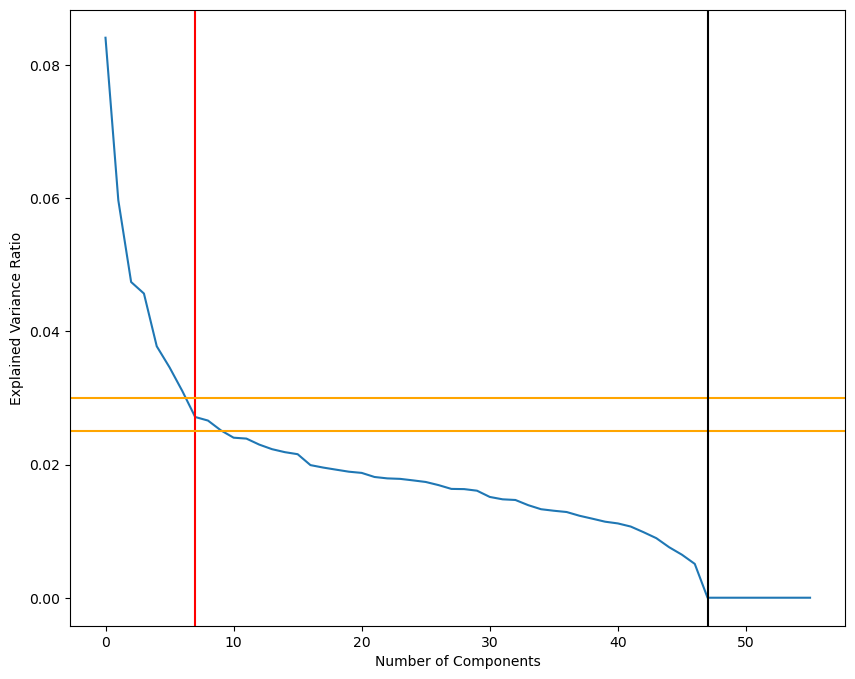

In [11]:
fig = plt.figure(figsize=(10,8))
plt.plot(pca.explained_variance_ratio_)
plt.xlabel('Number of Components')
plt.ylabel('Explained Variance Ratio')
plt.axvline(x=7, c='red')
plt.axhline(y=0.03, c='orange')
plt.axhline(y=0.025, c='orange')
plt.axvline(x=47, c='black')
plt.show();

Elbow for this graphs occurs at ~ 7 components, variance ratio somewhere between 0.025 and 0.03. Components past 46 offer no variance.

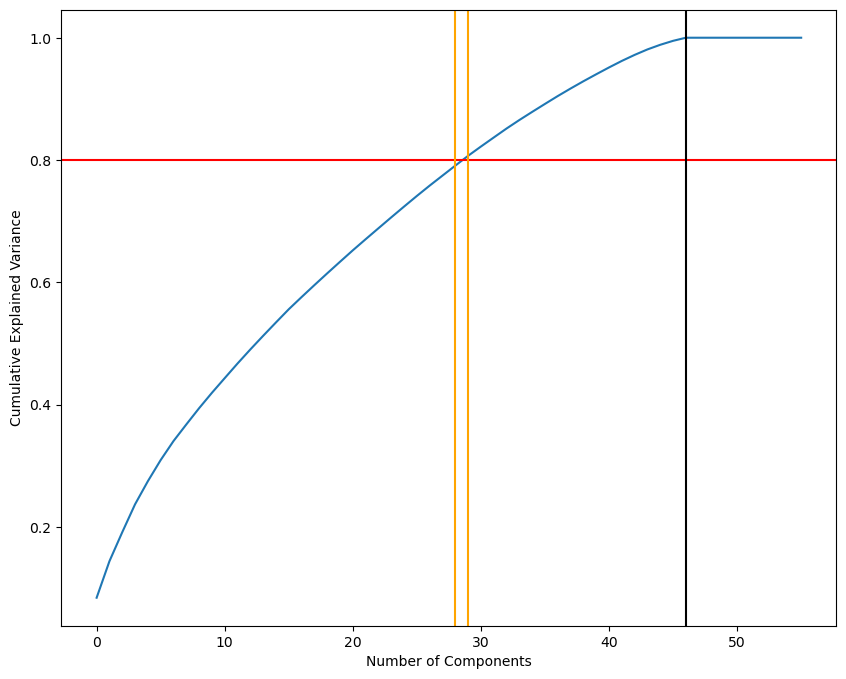

In [12]:
figure = plt.figure(figsize=(10,8))
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.axhline(y=0.8, c='red')
plt.axvline(x=28, c='orange')
plt.axvline(x=29, c='orange')
plt.axvline(x=46, c='black')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.show();

80% of cumulative variance is explained by ~29 components. 100% of cumulative variance explained by 46 components.

With these results, I will move forward with a PCA object using 29 components.

In [13]:
pca = PCA(n_components = 29)
df_pca = pca.fit_transform(df_scaled)

In [14]:
pca_viz = PCA(n_components = 2)
df_pca_viz = pca_viz.fit_transform(df_scaled)

Now we can look at the resulting components and get a sense of some groups that may have formed. I will write a function to do this so I can use it on multiple components, inlcuding in the nonvolunteer section, while saving code space.

I will look at the first 7 components, since that's where the elbow in our explained variance ratio graph occurred.

In [15]:
def get_weights(s_pca, component_num, col_list):
    col_name = 'PC_'+str(component_num + 1)
    
    pca_weights = pd.DataFrame(
        s_pca.components_[component_num].T,  
        index=col_list,
        columns=[col_name]
    )
    
    # Print the top 10 features associated with the principal component, sorted by absolute value of weight
    print("Top positive:")
    print(pca_weights.sort_values(by=col_name, ascending=False).head(10))
    print("\nTop negative:")
    print(pca_weights.sort_values(by=col_name, ascending=True).head(10))
    print('----------------------------------------------------------')
    
    return pca_weights

In [16]:
col_list = df_features.columns

In [17]:
for pc in range(7):
    get_weights(pca, pc, col_list)

Top positive:
                      PC_1
voterstatus_Yes   0.276473
age_encoded       0.255863
hetenure_Owned    0.245084
ntalk_encoded     0.224342
nissues_encoded   0.217398
favors_encoded    0.202352
news_encoded      0.183634
ffissues_encoded  0.182883
donate_Yes        0.180291
contact_Yes       0.178578

Top negative:
                              PC_1
hetenure_Rented          -0.245826
voterstatus_No           -0.240292
pemaritl_NEVER MARRIED   -0.213978
citizen_type_Non         -0.152796
voterstatus_NA           -0.122321
work_status_Employed     -0.121054
simrace_Black            -0.104588
simrace_Asian            -0.100702
citizen_type_Naturalized -0.073065
hrnumhou                 -0.052224
----------------------------------------------------------
Top positive:
                              PC_2
work_status_Employed      0.379303
hhincome_encoded          0.359455
hrnumhou                  0.280860
pemaritl_MARRIED          0.254981
ed_level_encoded          0.213600
hubus_

Let's tabulate this information to be easier to read:

| Component_Num | Positively-Pointed Features | Negatively-Pointed Features |
| ------------- | --------------------------- | --------------------------- |
| 1 | local voter, age, homeowner, interactions w/ neighbors, news consumption, donates non-politically, contacts politicians | renter, inelligible or non-local voter, never married, non-citizen or naturalized, employed, black or asian, household size |
| 2 | employed, income, married, education level, business owner, lives in a house, asian, homeowner, naturalized | not working, age, widowed, disabled, lives in mobile home, divorced, citizen, metro/non-metro, renter, veteran |
| 3 | citizen, white, homeowner, midwestern, married, metro/non-metro, non-local voter, household size, hispanic/non-hispanic, income | asian or black, naturalized or non-citizen, talking w/ neighbors/family/friends about issues, sharing views online, engages with local issues |
| 4 | citizen, never married or divorced, renter, employed, talking w/ family/friends about issues, participated in a boycott, contacts politicians, sharing views online, local voter | married, homeowner, naturalized or non-citizen, not working, asian, age, household size, inelligible or non-local voter |
| 5 | lives in a house, local voter, education level, age, not working, news consumption, hispanic/non-hispanic, widowed, black or asian | lives in a mobile home, interactions with neighbors, engages with local issues, household size, non-local voter, metro/non-metro, business owner, white |
| 6 | lives in a house, white, interactions with neighbors, non-local voter, renter, midwestern, engages with local issues, talking with family/friends | lives in a mobile home, black or asian, local voter, southern, homeowner, education level, hispanic/non-hispanic, naturalized, donates politically |
| 7 | southern, black, interactions with neighbors, hispanic/non-hispanic, citizen, engages with local issues, lives in a house, non-local voter | western or northeastern, white, participated in a boycott, lives in a mobile home, naturalized or non-citizen, local voter, contacts politicians, renter |

### Clustering

In [18]:
clusters = range (1, 20)
scores = []

for c in clusters:
    km_model = KMeans(n_clusters = c, random_state = 42)
    km_model.fit(df_pca)
    
    scores.append(km_model.score(df_pca))

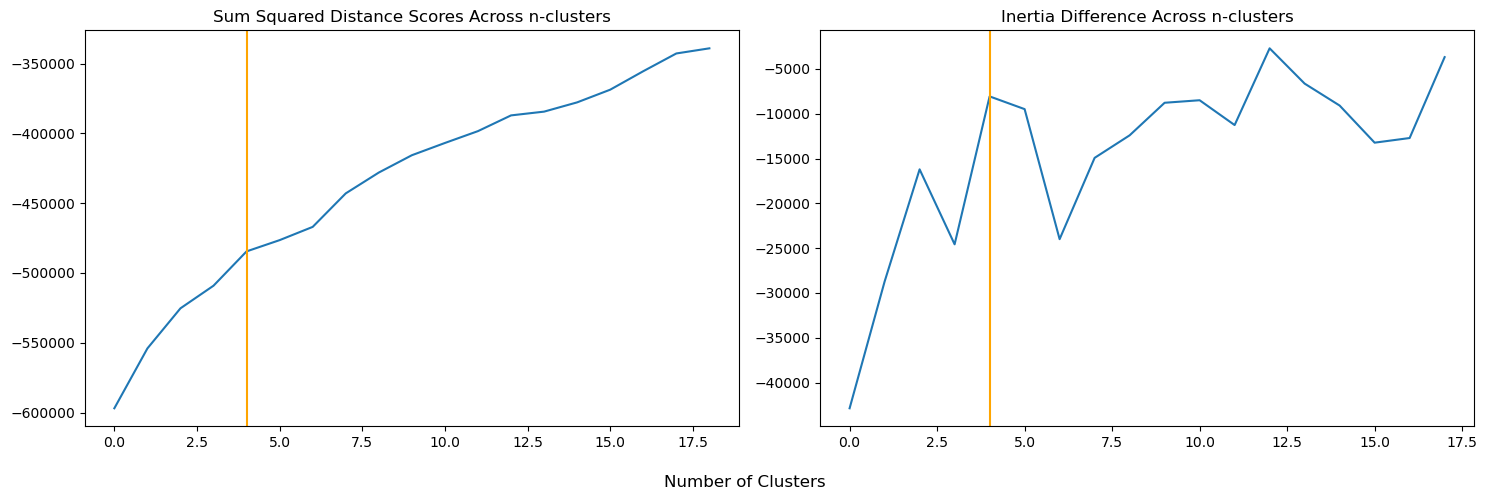

In [19]:
score_diff = []

for s in range(len(scores) - 1):
    score_diff.append(scores[s] - scores[s+1])
    
fig, (ax, bx) = plt.subplots(1,2, figsize=(15,5))
fig.supxlabel('Number of Clusters')
ax.set_title('Sum Squared Distance Scores Across n-clusters')
bx.set_title('Inertia Difference Across n-clusters')
ax.plot(scores)
bx.plot(score_diff)
ax.axvline(x=4, c='orange')
bx.axvline(x=4, c='orange')
plt.tight_layout()
plt.show()

There's a bit of an elbow at 4 clusters on the sum squared distance scores plot but it is not a dramatic plot by any means. The inertia plot is chaotic, but somewhere in the realm of 3-4 clusters seems to be a general inflection point. We'll move forward with 4 clusters.

In [20]:
km_model = KMeans(n_clusters=4, random_state=42)
volunteers = km_model.fit_predict(df_pca)

In [21]:
df_v['cluster'] = volunteers

Here is where we will bring in the nonresponse weights provided by the dataset. We'll use them to profile the data and see which clusters are most and least prevalent in the overall population.

In [22]:
cluster_weights = df_v.groupby('cluster')['supwgt'].sum()

In [23]:
cluster_share = cluster_weights / cluster_weights.sum()
idx = 0
for c in cluster_share:
    print(f"cluster {idx+1}: {c*100:.1f}%")
    idx+=1

cluster 1: 26.2%
cluster 2: 20.3%
cluster 3: 19.7%
cluster 4: 33.7%


This shows that, using the provided nonresponse weight, in an overall population the traits that direct cluster 4 are most prevalent, and those in clusters 2 and 3 are least prevalent. Now let's see what those traits are for each cluster:

In [24]:
centroids = km_model.cluster_centers_

In [25]:
centroids_scaled = pca.inverse_transform(centroids)

In [26]:
centroids_df = pd.DataFrame(centroids_scaled, columns=col_list)

In [27]:
for i in range(centroids_df.shape[0]):
    print(f"cluster {i+1}:\n{centroids_df.iloc[i].sort_values(ascending=False).head(10)}\n")

cluster 1:
voterstatus_No              0.896360
hetenure_Owned              0.470019
hrnumhou                    0.399447
simrace_Asian               0.378761
citizen_type_Naturalized    0.365438
work_status_Employed        0.283651
citizen_type_Non            0.247777
pemaritl_NEVER MARRIED      0.228219
voterstatus_NA              0.198449
housing_unit_Mobile         0.174718
Name: 0, dtype: float64

cluster 2:
work_status_Not Working    1.270575
age_encoded                1.028411
pemaritl_WIDOWED           0.517996
ntalk_encoded              0.380824
disability_Yes             0.380231
news_encoded               0.347096
hetenure_Owned             0.342447
voterstatus_Yes            0.334044
org_Yes                    0.286609
veteran_Yes                0.274870
Name: 1, dtype: float64

cluster 3:
hetenure_Rented           1.969435
pemaritl_NEVER MARRIED    0.820309
voterstatus_No            0.411898
citizen_type_Non          0.405469
simrace_Black             0.368606
work_status_

In [28]:
for i in range(centroids_df.shape[0]):
    print(f"cluster {i+1}:\n{centroids_df.iloc[i].sort_values(ascending=True).head(10)}\n")

cluster 1:
voterstatus_Yes        -0.939809
news_encoded           -0.522341
ffissues_encoded       -0.509679
age_encoded            -0.497026
hetenure_Rented        -0.469906
nissues_encoded        -0.453401
citizen_type_Citizen   -0.449632
ntalk_encoded          -0.411654
contact_Yes            -0.398093
donate_Yes             -0.375205
Name: 0, dtype: float64

cluster 2:
work_status_Employed     -1.240601
hrnumhou                 -0.520022
hhincome_encoded         -0.432865
hubus_YES                -0.377752
pemaritl_NEVER MARRIED   -0.359967
hetenure_Rented          -0.351191
voterstatus_No           -0.301923
citizen_type_Non         -0.190201
ed_level_encoded         -0.155956
simrace_Asian            -0.132926
Name: 1, dtype: float64

cluster 3:
hetenure_Owned            -1.941268
age_encoded               -0.758027
pemaritl_MARRIED          -0.683643
hhincome_encoded          -0.625822
voterstatus_Yes           -0.482350
simrace_White             -0.422436
ntalk_encoded        

### Analysis

Summarizing the above information:

| Cluster | Above-Average Features | Below-Average Features |
| ------------- | --------------------------- | --------------------------- |
| 1 | non-local or ineligble voter, homeowner, household size, Asian, naturalized or non-citizen, employed, never married, lives in a mobile home | local voter, news consumption, discusses issues friend/family/neighbors, age, renter, citizen, talks to neighbors, contacts politicians, donates non-politically |
| 2 | not working, age, widowed, talks to neighbors, disabled, news consumption, homeowner, local voter, belongs to organization(s), veteran | employed, household size, income, business owner, never married, renter, non-local voter, non-citizen, education level, Asian |
| 3 | renter, seperated or never married, non-local or ineligible voter, non-citizen, Black or Biracial, employed or unemployed | homeowner, age, married, income, local voter, White, talk to and does favors for neighbors, donates non-politically, not working |
| 4 | employed, income, local voter, homeowner, business owner, education level, married, discusses issues with friends/family, engages with local issues, household size | not working, non-local voter, renter, never married or widowed, disabled, non-citizen, Asian or Black, age |

I'm going to focus in on the features that pull points closer to the centroids of each cluster, the "above-average features". I'll be looking at a lot of columns in different clusters, so I'll use the below function to quickly print the information I want.

In [30]:
def cluster_exp(dataframe, cluster_idx, columns):
    for c in columns:
        print(f"{c}:\n")
        print(dataframe[dataframe['cluster'] == cluster_idx][c].describe())
        print('\n')
        print(dataframe[dataframe['cluster'] == cluster_idx][c].value_counts())
        print('----------------------------------------------')

A reminder that all individuals in this subset of data answered that they had volunteered in some capacity in the last 12 months.

#### Cluster 1 Exploration

In [31]:
cluster_exp(df_v, 0, centroids_df.iloc[0].sort_values(ascending=False).head(10).index)

voterstatus_No:

count    2831.000000
mean        0.648534
std         0.477512
min         0.000000
25%         0.000000
50%         1.000000
75%         1.000000
max         1.000000
Name: voterstatus_No, dtype: float64


voterstatus_No
1    1836
0     995
Name: count, dtype: int64
----------------------------------------------
hetenure_Owned:

count    2831.000000
mean        0.989403
std         0.102413
min         0.000000
25%         1.000000
50%         1.000000
75%         1.000000
max         1.000000
Name: hetenure_Owned, dtype: float64


hetenure_Owned
1    2801
0      30
Name: count, dtype: int64
----------------------------------------------
hrnumhou:

count    2831.000000
mean        3.100671
std         1.491591
min         1.000000
25%         2.000000
50%         3.000000
75%         4.000000
max        13.000000
Name: hrnumhou, dtype: float64


hrnumhou
2     854
4     630
3     535
1     342
5     302
6     118
7      34
8       9
10      2
9       2
13      2
11   

Within this cluster, the above average outcomes show individuals that:

- Are not active in local elections even if they are eligible to participate,
- Own their homes,
- Have 1-4 people in their home,
- Are not solely Asian by race,
- Are native citizens,
- Are employed,
- Have been married at some point, and
- Do not live in a mobile home

This sounds like a pretty stereotypical American household containing a small, working family in a static home that only votes during big elections.

#### Cluster 2 Exploration

In [32]:
cluster_exp(df_v, 1, centroids_df.iloc[1].sort_values(ascending=False).head(10).index)

work_status_Not Working:

count    3764.000000
mean        0.965197
std         0.183306
min         0.000000
25%         1.000000
50%         1.000000
75%         1.000000
max         1.000000
Name: work_status_Not Working, dtype: float64


work_status_Not Working
1    3633
0     131
Name: count, dtype: int64
----------------------------------------------
age_encoded:

count    3764.000000
mean        6.092986
std         1.112280
min         1.000000
25%         6.000000
50%         6.000000
75%         7.000000
max         8.000000
Name: age_encoded, dtype: float64


age_encoded
6    1595
7    1161
5     542
8     215
4     109
3     100
2      29
1      13
Name: count, dtype: int64
----------------------------------------------
pemaritl_WIDOWED:

count    3764.000000
mean        0.194208
std         0.395643
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max         1.000000
Name: pemaritl_WIDOWED, dtype: float64


pemaritl_WIDOWED
0    3033
1  

Within this cluster, the above average outcomes show individuals that:

- Are not working,
- Are in their mid-60s to mid 80s which is commonly a retiree age range,
- Are not widowed,
- Talk or spend time with their neighbors a few times a month,
- Are not disabled,
- Consume news about political, societal, or local issues basically every day,
- Own their home,
- Vote in local elections,
- Belong to at least one group, organization, or association, and
- Are not military veterans

This group paints a picture of the locally engaged, established, retiree who engages socially by being friendly with their neighbors or participating in group activities.

#### Cluster 3 Exploration

In [33]:
cluster_exp(df_v, 2, centroids_df.iloc[2].sort_values(ascending=False).head(10).index)

hetenure_Rented:

count    2341.000000
mean        0.979069
std         0.143185
min         0.000000
25%         1.000000
50%         1.000000
75%         1.000000
max         1.000000
Name: hetenure_Rented, dtype: float64


hetenure_Rented
1    2292
0      49
Name: count, dtype: int64
----------------------------------------------
pemaritl_NEVER MARRIED:

count    2341.000000
mean        0.500641
std         0.500106
min         0.000000
25%         0.000000
50%         1.000000
75%         1.000000
max         1.000000
Name: pemaritl_NEVER MARRIED, dtype: float64


pemaritl_NEVER MARRIED
1    1172
0    1169
Name: count, dtype: int64
----------------------------------------------
voterstatus_No:

count    2341.000000
mean        0.436138
std         0.496011
min         0.000000
25%         0.000000
50%         0.000000
75%         1.000000
max         1.000000
Name: voterstatus_No, dtype: float64


voterstatus_No
0    1320
1    1021
Name: count, dtype: int64
------------------------

Within this cluster, the above average outcomes show individuals that:

- Rent their homes,
- Are citizens,
- Are eligible voters that lean slightly towards not participating in local elections,
- Almost exactly 50/50 on ever being married, but not currently seperated,
- Are not solely Black nor Biracial by race,
- Are native citizens, and
- Are employed,

This group is a little hard to parse, it is the first primarily non-homeowner group but they fall in the middle in a couple of items such as local election participation and marriage status. These are working people who haven't hit certain milestones such has home ownership or marriage, and they don't inherently participate in local happenings. I find it interesting that certain class predictors, such as income or age, are so low on the scale for this group.

#### Cluster 4 Exploration

In [34]:
cluster_exp(df_v, 3, centroids_df.iloc[3].sort_values(ascending=False).head(10).index)

work_status_Employed:

count    4788.000000
mean        0.969298
std         0.172526
min         0.000000
25%         1.000000
50%         1.000000
75%         1.000000
max         1.000000
Name: work_status_Employed, dtype: float64


work_status_Employed
1    4641
0     147
Name: count, dtype: int64
----------------------------------------------
hhincome_encoded:

count    4788.000000
mean        4.031955
std         1.076566
min         1.000000
25%         3.000000
50%         4.000000
75%         5.000000
max         5.000000
Name: hhincome_encoded, dtype: float64


hhincome_encoded
5    2187
4    1133
3    1002
2     366
1     100
Name: count, dtype: int64
----------------------------------------------
voterstatus_Yes:

count    4788.000000
mean        0.953425
std         0.210748
min         0.000000
25%         1.000000
50%         1.000000
75%         1.000000
max         1.000000
Name: voterstatus_Yes, dtype: float64


voterstatus_Yes
1    4565
0     223
Name: count, dtype: 

Within this cluster, the above average outcomes show individuals that:

- Are employed,
- Are at least middle-class, but tend to be mid-upper / upper class,
- Vote locally,
- Own their home
- Are highly educated, holding either bachelor's or master's degrees,
- Are married,
- Talk or meet with their friends or family fairly frequently,
- Do not tend to attend public meetings, and
- Have 2-4 people living in their home

There are similarities between this cluster and the first, though this one focuses much more heavily on class indicators such as income and education level. They are highly educated, have higher income, own a home, are more active in local politics, are family-oriented, and connect with their loved ones regularly.

### Conclusion

Referring back to those prevelance statistics:
```
cluster 1: 26.2%
cluster 2: 20.3%
cluster 3: 19.7%
cluster 4: 33.7%
```
The clear overlaps in the most prevelant clusters are small, working families living in homes they own. Let's see if there are other characteristics of interest:

In [46]:
df_v[(df_v['cluster'] == 0) | (df_v['cluster'] == 3)].drop(columns=['supwgt', 'cluster']).describe().loc['mean'].sort_values(ascending=False)

ed_level_encoded            11.184539
fftalk_encoded               4.514372
hhincome_encoded             3.842368
news_encoded                 3.838955
age_encoded                  3.759286
hrnumhou                     3.016275
ffissues_encoded             2.756530
ntalk_encoded                2.687623
favors_encoded               1.873080
nissues_encoded              1.097651
housing_unit_House           0.980050
hetenure_Owned               0.972831
pehspnon_NON-HISPANIC        0.926893
citizen_type_Citizen         0.909962
work_status_Employed         0.902087
simrace_White                0.870718
donate_Yes                   0.823205
pemaritl_MARRIED             0.730148
voterstatus_Yes              0.706917
org_Yes                      0.606379
pesex_MALE                   0.454653
views_encoded                0.445203
action_Yes                   0.428403
boycott_Yes                  0.339808
gereg_SOUTH                  0.317364
gereg_WEST                   0.273920
voterstatus_

Within the clusters that collectively hold ~60% of the population prevelance, we're looking at primarily college educated, family-oriented, working upper-middle class citizens. Demographically they are largely non-hispanic, white, in their late 30s / early 40s, and married. They tend to live in metropolitan areas, are able-bodied, are not military veterans. Their civic engagment activities are most commonly consuming news, talking with family, friends, and neighbors, voting locally, donating to non-political organizations, and being part of groups, organizations, or associations.

Our less prevelant clusters have pretty much no overlap in key features, I'll look at their full feature averages seperately.

In [49]:
df_v[df_v['cluster'] == 1].drop(columns=['supwgt', 'cluster']).describe().loc['mean'].sort_values(ascending=False)

ed_level_encoded            10.637620
age_encoded                  6.092986
fftalk_encoded               4.507173
news_encoded                 4.437566
ntalk_encoded                3.336610
ffissues_encoded             2.893996
hhincome_encoded             2.807917
favors_encoded               2.276036
hrnumhou                     1.901435
nissues_encoded              1.492295
pehspnon_NON-HISPANIC        0.980871
housing_unit_House           0.974761
citizen_type_Citizen         0.969979
work_status_Not Working      0.965197
hetenure_Owned               0.930925
simrace_White                0.918969
donate_Yes                   0.886291
voterstatus_Yes              0.871148
org_Yes                      0.745749
pemaritl_MARRIED             0.641073
views_encoded                0.555526
action_Yes                   0.532678
pesex_MALE                   0.378587
gereg_SOUTH                  0.331562
boycott_Yes                  0.321732
gereg_WEST                   0.266738
contact_Yes 

This is an older White (non-hispanic), predominately female cohort (averaging mid 60s), usually still married but about 20% have lost their spouse and 10% are divorced, they have some higher education and own / live in a home in a metropolitan area, but income is slightly below middle class as they are not working ( 22% of these folks are disabled, I imagine most of the rest to be retired). They are pretty talkative and friendly with neighbors and family / friends, large majority donate non-politically, vote in local elections, belong to a group, organization, or association, and a little over half even get together with people in their community to do something positive for it. A very civically engaged cluster.

In [50]:
df_v[df_v['cluster'] == 2].drop(columns=['supwgt', 'cluster']).describe().loc['mean'].sort_values(ascending=False)

ed_level_encoded            10.366937
fftalk_encoded               4.361811
news_encoded                 3.559590
age_encoded                  2.930799
hhincome_encoded             2.612559
ffissues_encoded             2.569415
hrnumhou                     2.323366
ntalk_encoded                2.113199
favors_encoded               1.315677
hetenure_Rented              0.979069
housing_unit_House           0.978214
pehspnon_NON-HISPANIC        0.844938
citizen_type_Citizen         0.842802
work_status_Employed         0.780436
nissues_encoded              0.743272
simrace_White                0.707817
donate_Yes                   0.645451
views_encoded                0.639897
pemaritl_NEVER MARRIED       0.500641
voterstatus_Yes              0.496369
org_Yes                      0.463050
voterstatus_No               0.436138
pesex_MALE                   0.412644
gereg_SOUTH                  0.345152
action_Yes                   0.320803
gereg_WEST                   0.313541
pemaritl_MAR

This is the youngest cohort, averaging in their early 30s, have some level of higher education, working for lower-middle class wages. They are very engaged with family and friends, but not much with their neighbors other than the occasional favor, ~2/3rds do donate non-politically, and they are more vocal than their other-cluster peers when it comes to sharing their views on political, societal, or local issues online. They live in rented houses in metropolitan areas, and with household sizes averaging just over 2 and half of these folks having never married, there is a pretty high likelihood that the other individual(s) living with them are either roommates or un-married partners.

## Non-Volunteer Segments

In [39]:
df_nv = pd.read_csv('../data/processed/cev_nonvolunteers.csv')

In [40]:
df_features = df_nv.drop(columns=['supwgt'])

### Feature Scaling

In [41]:
df_scaled = scaler.fit_transform(df_features)

### Dimensionality Reduction & Principal Component Analysis

In [42]:
pca = PCA()
pca.fit(df_scaled)

,"n_components n_components: int, float or 'mle', default=NoneNumber of components to keep.if n_components is not set all components are kept:: n_components == min(n_samples, n_features)If ``n_components == 'mle'`` and ``svd_solver == 'full'``, Minka'sMLE is used to guess the dimension. Use of ``n_components == 'mle'``will interpret ``svd_solver == 'auto'`` as ``svd_solver == 'full'``.If ``0 < n_components < 1`` and ``svd_solver == 'full'``, select thenumber of components such that the amount of variance that needs to beexplained is greater than the percentage specified by n_components.If ``svd_solver == 'arpack'``, the number of components must bestrictly less than the minimum of n_features and n_samples.Hence, the None case results in:: n_components == min(n_samples, n_features) - 1",None
,"copy copy: bool, default=TrueIf False, data passed to fit are overwritten and runningfit(X).transform(X) will not yield the expected results,use fit_transform(X) instead.",True
,"whiten whiten: bool, default=FalseWhen True (False by default) the `components_` vectors are multipliedby the square root of n_samples and then divided by the singular valuesto ensure uncorrelated outputs with unit component-wise variances.Whitening will remove some information from the transformed signal(the relative variance scales of the components) but can sometimeimprove the predictive accuracy of the downstream estimators bymaking their data respect some hard-wired assumptions.",False
,"svd_solver svd_solver: {'auto', 'full', 'covariance_eigh', 'arpack', 'randomized'}, default='auto'""auto"" : The solver is selected by a default 'auto' policy is based on `X.shape` and `n_components`: if the input data has fewer than 1000 features and more than 10 times as many samples, then the ""covariance_eigh"" solver is used. Otherwise, if the input data is larger than 500x500 and the number of components to extract is lower than 80% of the smallest dimension of the data, then the more efficient ""randomized"" method is selected. Otherwise the exact ""full"" SVD is computed and optionally truncated afterwards.""full"" : Run exact full SVD calling the standard LAPACK solver via `scipy.linalg.svd` and select the components by postprocessing""covariance_eigh"" : Precompute the covariance matrix (on centered data), run a classical eigenvalue decomposition on the covariance matrix typically using LAPACK and select the components by postprocessing. This solver is very efficient for n_samples >> n_features and small n_features. It is, however, not tractable otherwise for large n_features (large memory footprint required to materialize the covariance matrix). Also note that compared to the ""full"" solver, this solver effectively doubles the condition number and is therefore less numerical stable (e.g. on input data with a large range of singular values).""arpack"" : Run SVD truncated to `n_components` calling ARPACK solver via `scipy.sparse.linalg.svds`. It requires strictly `0 < n_components < min(X.shape)`""randomized"" : Run randomized SVD by the method of Halko et al... versionadded:: 0.18.0.. versionchanged:: 1.5 Added the 'covariance_eigh' solver.",'auto'
,"tol tol: float, default=0.0Tolerance for singular values computed by svd_solver == 'arpack'.Must be of range [0.0, infinity)... versionadded:: 0.18.0",0.0
,"iterated_power iterated_power: int or 'auto', default='auto'Number of iterations for the power method computed bysvd_solver == 'randomized'.Must be of range [0, infinity)... versionadded:: 0.18.0",'auto'
,"n_oversamples n_oversamples: int, default=10This parameter is only relevant when `svd_solver=""randomized""`.It corresponds to the additional number of random vectors to sample therange of `X` so as to ensure proper conditioning. See:func:`~sklearn.utils.extmath.randomized_svd` for more details... versionadded:: 1.1",10
,"power_iteration_normalizer power_iteration_normalizer: {'auto', 'QR', 'LU', 'none'}, default='auto'Power iteration normalizer for randomized S

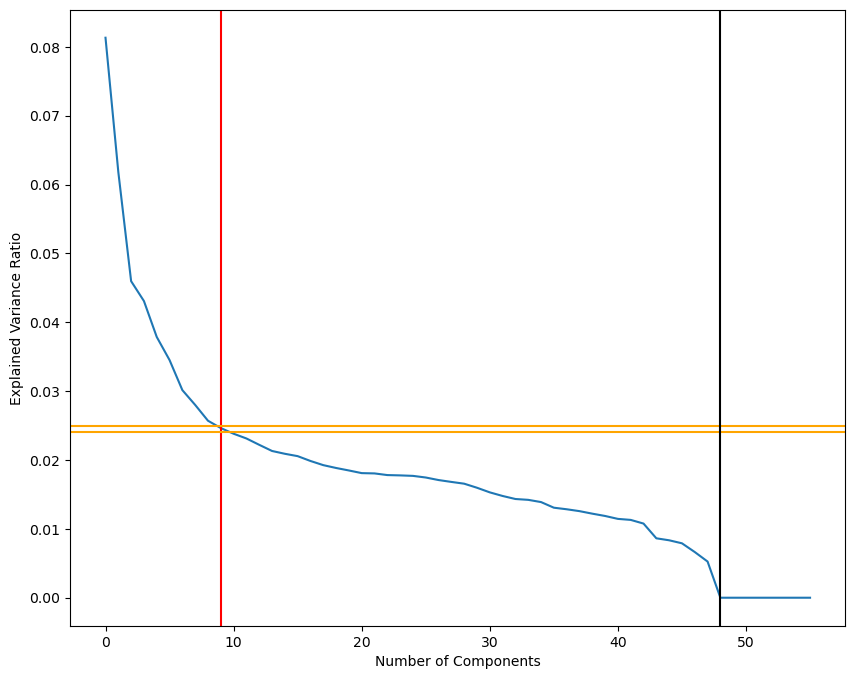

In [43]:
fig = plt.figure(figsize=(10,8))
plt.plot(pca.explained_variance_ratio_)
plt.xlabel('Number of Components')
plt.ylabel('Explained Variance Ratio')
plt.axvline(x=9, c='red')
plt.axhline(y=0.024, c='orange')
plt.axhline(y=0.025, c='orange')
plt.axvline(x=48, c='black')
plt.show();

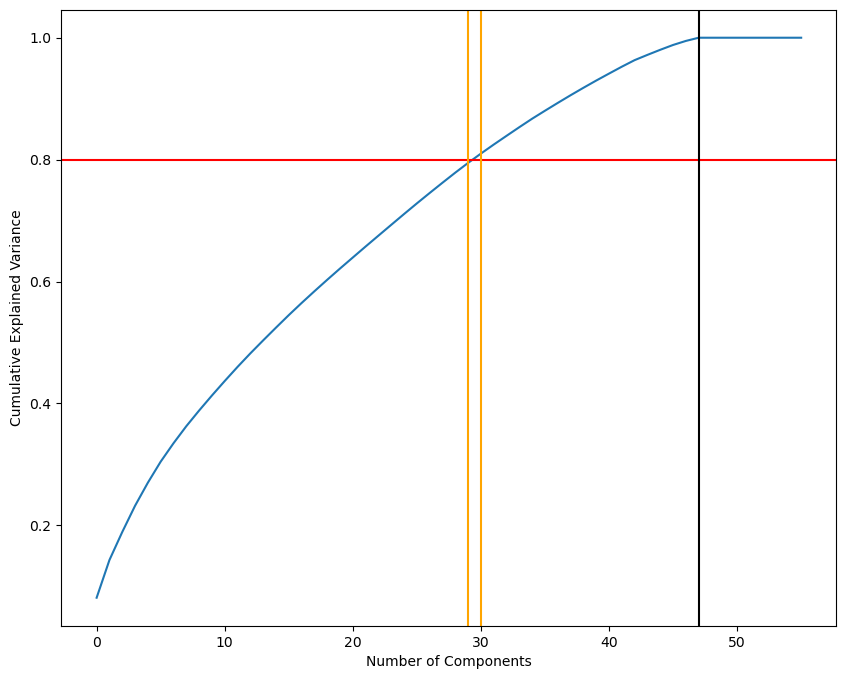

In [44]:
figure = plt.figure(figsize=(10,8))
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.axhline(y=0.8, c='red')
plt.axvline(x=30, c='orange')
plt.axvline(x=29, c='orange')
plt.axvline(x=47, c='black')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.show();

In [45]:
pca = PCA(n_components = 30)
df_pca = pca.fit_transform(df_scaled)

In [46]:
for pc in range(9):
    get_weights(pca, pc, col_list)

Top positive:
                          PC_1
voterstatus_Yes       0.288263
hetenure_Owned        0.248243
age_encoded           0.238677
donate_Yes            0.222722
news_encoded          0.214576
ntalk_encoded         0.210859
favors_encoded        0.193654
ffissues_encoded      0.185686
citizen_type_Citizen  0.183021
nissues_encoded       0.181499

Top negative:
                              PC_1
hetenure_Rented          -0.246878
voterstatus_No           -0.241210
pemaritl_NEVER MARRIED   -0.199078
citizen_type_Non         -0.182977
voterstatus_NA           -0.119668
hrnumhou                 -0.097121
work_status_Employed     -0.096499
simrace_Black            -0.077886
simrace_Asian            -0.075498
citizen_type_Naturalized -0.066802
----------------------------------------------------------
Top positive:
                              PC_2
work_status_Not Working   0.399650
age_encoded               0.294104
disability_Yes            0.282636
pemaritl_WIDOWED          0.2310

### Clustering

In [47]:
clusters = range (1, 20)
scores = []

for c in clusters:
    km_model = KMeans(n_clusters = c, random_state = 42)
    km_model.fit(df_pca)
    
    scores.append(km_model.score(df_pca))

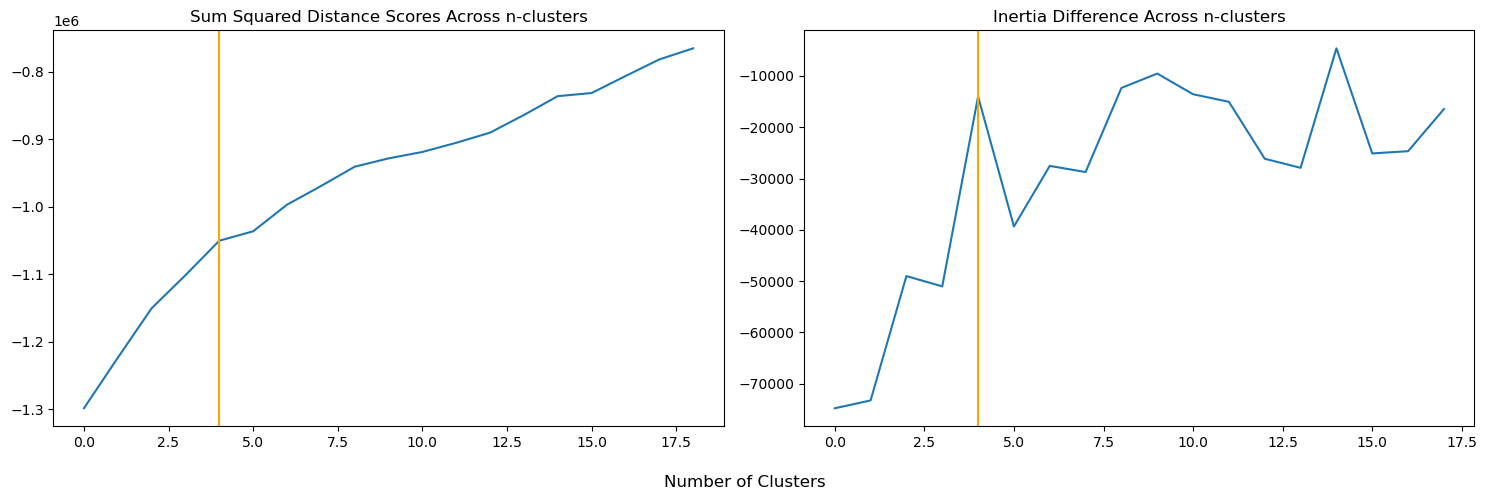

In [48]:
score_diff = []

for s in range(len(scores) - 1):
    score_diff.append(scores[s] - scores[s+1])
    
fig, (ax, bx) = plt.subplots(1,2, figsize=(15,5))
fig.supxlabel('Number of Clusters')
ax.set_title('Sum Squared Distance Scores Across n-clusters')
bx.set_title('Inertia Difference Across n-clusters')
ax.plot(scores)
bx.plot(score_diff)
ax.axvline(x=4, c='orange')
bx.axvline(x=4, c='orange')
plt.tight_layout()
plt.show();

In [49]:
km_model = KMeans(n_clusters=4, random_state=42)
nonvolunteers = km_model.fit_predict(df_pca)

In [50]:
df_nv['cluster'] = nonvolunteers

In [51]:
cluster_weights = df_nv.groupby('cluster')['supwgt'].sum()

In [52]:
cluster_share = cluster_weights / cluster_weights.sum()
idx = 0
for c in cluster_share:
    print(f"cluster {idx}: {c*100:.1f}%")
    idx+=1

cluster 0: 19.2%
cluster 1: 19.7%
cluster 2: 36.1%
cluster 3: 25.1%


In [53]:
centroids = km_model.cluster_centers_
centroids_scaled = pca.inverse_transform(centroids)
centroids_df = pd.DataFrame(centroids_scaled, columns=col_list)

In [54]:
for i in range(centroids_df.shape[0]):
    print(f"cluster {i+1}:\n{centroids_df.iloc[i].sort_values(ascending=False).head(10)}\n")

cluster 1:
citizen_type_Naturalized    1.538428
citizen_type_Non            1.472342
simrace_Asian               1.137355
voterstatus_NA              0.976910
hrnumhou                    0.434791
hetenure_Rented             0.383067
pemaritl_MARRIED            0.244006
voterstatus_No              0.194735
work_status_Employed        0.176137
gereg_WEST                  0.176062
Name: 0, dtype: float64

cluster 2:
work_status_Not Working     1.044243
age_encoded                 0.914470
disability_Yes              0.666393
pemaritl_WIDOWED            0.592962
citizen_type_Citizen        0.364183
pehspnon_NON-HISPANIC       0.302729
veteran_Yes                 0.293101
gtmetsta_NONMETROPOLITAN    0.252254
hetenure_Owned              0.213723
pemaritl_DIVORCED           0.205151
Name: 1, dtype: float64

cluster 3:
pemaritl_NEVER MARRIED    0.821856
voterstatus_No            0.511937
hetenure_Rented           0.485863
work_status_Employed      0.468629
citizen_type_Citizen      0.367120
si

In [55]:
for i in range(centroids_df.shape[0]):
    print(f"cluster {i+1}:\n{centroids_df.iloc[i].sort_values(ascending=True).head(10)}\n")

cluster 1:
citizen_type_Citizen       -2.220899
pehspnon_NON-HISPANIC      -1.089985
voterstatus_Yes            -0.579359
simrace_White              -0.557585
gtmetsta_NONMETROPOLITAN   -0.437555
ed_level_encoded           -0.389043
hetenure_Owned             -0.372004
boycott_Yes                -0.309108
veteran_Yes                -0.304871
ffissues_encoded           -0.231133
Name: 0, dtype: float64

cluster 2:
work_status_Employed       -1.006336
hhincome_encoded           -0.557181
hrnumhou                   -0.489363
pemaritl_NEVER MARRIED     -0.414552
ed_level_encoded           -0.298102
hubus_YES                  -0.279687
citizen_type_Non           -0.266850
citizen_type_Naturalized   -0.227543
hetenure_Rented            -0.223053
simrace_Asian              -0.212189
Name: 1, dtype: float64

cluster 3:
age_encoded                -0.820202
pemaritl_MARRIED           -0.534634
work_status_Not Working    -0.514684
hetenure_Owned             -0.489817
voterstatus_Yes            -0